In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

try:
    import ruptures as rpt
    HAS_RUPTURES = True
except ImportError:
    rpt = None
    HAS_RUPTURES = False


In [2]:
base_dir = Path.cwd()
data_candidates = [
    base_dir / 'A_DeviceMotion_data 복사본' / 'HAR_total.compat.csv.gz',
    base_dir / 'HAR_total.compat.csv.gz',
    base_dir.parent / 'A_DeviceMotion_data 복사본' / 'HAR_total.compat.csv.gz',
]

har_path = next((path for path in data_candidates if path.exists()), None)
if har_path is None:
    raise FileNotFoundError('HAR_total.compat.csv.gz 파일을 찾지 못했습니다.')

har_total = pd.read_csv(har_path)
if 'Unnamed: 0' in har_total.columns:
    har_total = har_total.drop(columns=['Unnamed: 0'])

print('base_dir:', base_dir)
print('har_path:', har_path)
print('shape:', har_total.shape)
har_total.head()


base_dir: /Users/jsh/Desktop/class/3-1/비정형데이터분석/실습
har_path: /Users/jsh/Desktop/class/3-1/비정형데이터분석/실습/A_DeviceMotion_data 복사본/HAR_total.compat.csv.gz
shape: (1412865, 17)


,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


## 1. 변화점 특징 만들기

`ruptures`가 있으면 새로 계산하고,
없으면 기존 `changepoint_features.csv`를 그대로 사용합니다.


In [3]:
changepoint_path = base_dir / 'changepoint_features.csv'

def count_changepoints(signal, model, min_size=20, jump=20, pen=20, sample_step=5):
    # 계산량을 줄이기 위해 일부 샘플만 사용합니다.
    values = np.asarray(signal, dtype=float)
    values = values[np.isfinite(values)][::sample_step]

    # 너무 짧은 구간은 변화점을 안정적으로 찾기 어렵습니다.
    if len(values) < max(min_size * 2, 40):
        return 0

    if not HAS_RUPTURES:
        raise ImportError('ruptures 패키지가 필요합니다.')

    algo = rpt.Binseg(model=model, min_size=min_size, jump=jump)
    try:
        return len(algo.fit(values).predict(pen=pen)) - 1
    except Exception:
        return 0

def build_changepoint_features(dataframe):
    rows = []
    grouped = dataframe.groupby(['id', 'exp_no', 'activity'], sort=False)

    for idx, ((subject_id, exp_no, activity), group) in enumerate(grouped, start=1):
        rotation = group['magrotationRate'].to_numpy(dtype=float)
        accel = group['maguserAcceleration'].to_numpy(dtype=float)
        rows.append({
            'id': str(subject_id),
            'exp_no': str(exp_no),
            'activity': activity,
            'cp1': count_changepoints(rotation, model='l2'),
            'cp2': count_changepoints(accel, model='l2'),
            'cp3': count_changepoints(rotation, model='normal'),
            'cp4': count_changepoints(accel, model='normal'),
            'cp5': count_changepoints(rotation, model='rbf'),
            'cp6': count_changepoints(accel, model='rbf'),
        })

        if idx % 30 == 0 or idx == grouped.ngroups:
            print(f'{idx}/{grouped.ngroups} groups processed')

    return pd.DataFrame(rows)

if HAS_RUPTURES:
    changepoint_features = build_changepoint_features(har_total)
    changepoint_features.to_csv(changepoint_path, index=False)
    print('변화점 특징을 새로 계산해 저장했습니다.')
elif changepoint_path.exists():
    changepoint_features = pd.read_csv(changepoint_path)
    print('기존 changepoint_features.csv를 불러왔습니다.')
else:
    raise ImportError('ruptures가 없고 changepoint_features.csv도 없습니다.')

changepoint_features['id'] = changepoint_features['id'].astype(str)
changepoint_features['exp_no'] = changepoint_features['exp_no'].astype(str)
cp_cols = ['cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6']
changepoint_features.head()


30/360 groups processed
60/360 groups processed
90/360 groups processed
120/360 groups processed
150/360 groups processed
180/360 groups processed
210/360 groups processed
240/360 groups processed
270/360 groups processed
300/360 groups processed
330/360 groups processed
360/360 groups processed
변화점 특징을 새로 계산해 저장했습니다.


,id,exp_no,activity,cp1,cp2,cp3,cp4,cp5,cp6
0,12,11,dws,0,0,0,1,0,0
1,1,11,dws,0,0,0,0,0,0
2,13,11,dws,0,0,0,0,0,0
3,11,11,dws,0,0,0,0,0,0
4,2,11,dws,0,0,0,0,0,0


,cp1,cp2,cp3,cp4,cp5,cp6
activity,,,,,,
dws,0.12,0.00,0.24,0.67,0.00,0.00
jog,0.65,0.08,0.38,0.48,0.00,0.00
sit,0.06,0.00,21.35,18.50,0.88,2.77
std,0.04,0.00,19.00,17.33,0.71,2.12
ups,0.07,0.00,0.19,0.86,0.00,0.00
wlk,0.26,0.04,0.40,1.15,0.03,0.12


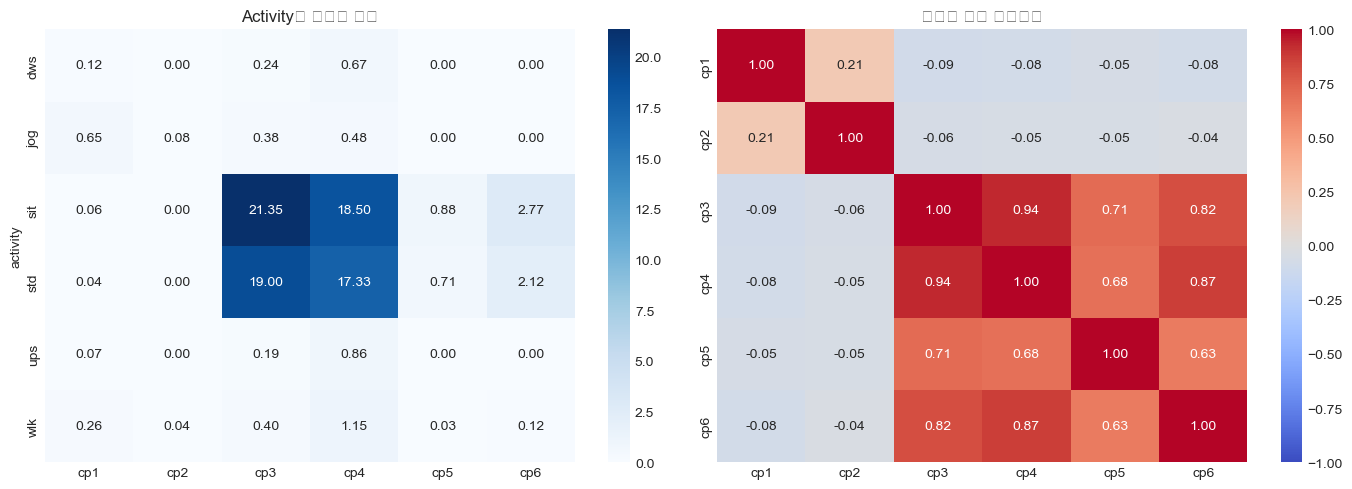

In [4]:
activity_cp_mean = changepoint_features.groupby('activity')[cp_cols].mean().round(2)
display(activity_cp_mean)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(activity_cp_mean, annot=True, fmt='.2f', cmap='Blues', ax=axes[0])
axes[0].set_title('Activity별 변화점 평균')

corr = changepoint_features[cp_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('변화점 특징 상관관계')

plt.tight_layout()
plt.show()

## 2. 피크 특징 만들기

피크 개수와 간격, 피크 높이 통계를 계산,
기존 `peak_features.csv`가 있으면 재사용


In [5]:
peak_path = base_dir / 'peak_features.csv'

def peak_table(signal, threshold=4.0, top_n=None):
    # threshold보다 큰 국소 최대값만 피크로 봅니다.
    values = np.asarray(signal, dtype=float)
    peak_idx, props = find_peaks(values, height=threshold)
    peaks = pd.DataFrame({
        'peak_height': props.get('peak_heights', np.array([], dtype=float)),
        'peak_index': peak_idx,
    }).sort_values('peak_height', ascending=False)
    return peaks.head(top_n) if top_n else peaks

def crest_factor(values):
    # 최대 진폭과 RMS의 비율을 계산합니다.
    values = np.asarray(values, dtype=float)
    rms = np.sqrt(np.mean(values ** 2))
    return 0.0 if rms == 0 else float(np.max(np.abs(values)) / rms)

def peak_stats(peaks):
    peak_positions = np.sort(peaks['peak_index'].to_numpy()) if len(peaks) else np.array([])
    peak_values = peaks['peak_height'].to_numpy(dtype=float) if len(peaks) else np.array([])
    intervals = np.diff(peak_positions) if len(peaks) >= 2 else np.array([])

    return {
        'f_n': int(len(peaks)),
        'p_interval': float(intervals.mean()) if len(intervals) else 0.0,
        'p_interval_std': float(intervals.std(ddof=1)) if len(intervals) >= 2 else 0.0,
        'p_mean': float(peak_values.mean()) if len(peak_values) else 0.0,
        'p_max': float(peak_values.max()) if len(peak_values) else 0.0,
        'p_min': float(peak_values.min()) if len(peak_values) else 0.0,
        'p_std': float(peak_values.std(ddof=1)) if len(peak_values) >= 2 else 0.0,
    }

def build_peak_features(dataframe, threshold=4.0):
    rows = []
    grouped = dataframe.groupby(['exp_no', 'id', 'activity'], sort=True)

    for (exp_no, sid, activity), group in grouped:
        rotation = group['magrotationRate'].to_numpy(dtype=float)
        accel = group['maguserAcceleration'].to_numpy(dtype=float)
        peaks = peak_table(rotation, threshold=threshold)
        stats = peak_stats(peaks)
        rows.append({
            'exp_no': str(exp_no),
            'id': str(sid),
            'activity': activity,
            'cfR': crest_factor(rotation),
            'cfA': crest_factor(accel),
            **stats,
        })

    return pd.DataFrame(rows)

if peak_path.exists():
    peak_features = pd.read_csv(peak_path)
    print('기존 peak_features.csv를 불러왔습니다.')
else:
    peak_features = build_peak_features(har_total, threshold=4.0)
    peak_features.to_csv(peak_path, index=False)
    print('피크 특징을 새로 계산해 저장했습니다.')

peak_features['id'] = peak_features['id'].astype(str)
peak_features['exp_no'] = peak_features['exp_no'].astype(str)
peak_cols = [col for col in peak_features.columns if col not in ['exp_no', 'id', 'activity']]
peak_features.head()


기존 peak_features.csv를 불러왔습니다.


,exp_no,id,activity,cfR,cfA,f_n,p_interval,p_interval_std,p_mean,p_max,p_min,p_std
0,1,1,dws,2.992226,3.456021,67,25.909091,18.356509,4.821695,7.138682,4.013819,0.566890
1,11,1,dws,2.750435,3.882361,38,23.513514,18.923204,4.653541,6.627259,4.004458,0.627969
2,12,1,ups,2.588530,3.941039,50,20.795918,16.164940,5.185460,7.239072,4.041368,0.824738
3,13,1,sit,11.627549,12.206843,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,14,1,std,5.925252,4.717860,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 3. 원본 센서 축 전체 요약 통계 만들기

정확도를 높이기 위해 변화점/피크 특징만 사용x,
원본 센서 각 축의 평균, 표준편차, 최소/최대, 중앙값, 왜도까지 사용


In [6]:
summary_path = base_dir / 'sensor_summary_features.csv'

base_sensor_cols = [
    'attitude.roll', 'attitude.pitch', 'attitude.yaw',
    'gravity.x', 'gravity.y', 'gravity.z',
    'rotationRate.x', 'rotationRate.y', 'rotationRate.z',
    'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z',
    'maguserAcceleration', 'magrotationRate',
]

summary_features = (
    har_total.groupby(['exp_no', 'id', 'activity'], sort=True)[base_sensor_cols]
    .agg(['mean', 'std', 'min', 'max', 'median', 'skew'])
)
summary_features.columns = [f'{col}_{stat}' for col, stat in summary_features.columns]
summary_features = summary_features.reset_index()

# 회전축과 가속도축의 전체 변동성을 비교하는 파생변수입니다.
summary_features['rot_xyz_std_sum'] = summary_features[
    ['rotationRate.x_std', 'rotationRate.y_std', 'rotationRate.z_std']
].sum(axis=1)
summary_features['acc_xyz_std_sum'] = summary_features[
    ['userAcceleration.x_std', 'userAcceleration.y_std', 'userAcceleration.z_std']
].sum(axis=1)
summary_features['rot_acc_std_ratio'] = (
    summary_features['rot_xyz_std_sum'] / (summary_features['acc_xyz_std_sum'] + 1e-6)
)
summary_features['mag_mean_gap'] = (
    summary_features['magrotationRate_mean'] - summary_features['maguserAcceleration_mean']
)
summary_features['mag_std_gap'] = (
    summary_features['magrotationRate_std'] - summary_features['maguserAcceleration_std']
)

summary_features['id'] = summary_features['id'].astype(str)
summary_features['exp_no'] = summary_features['exp_no'].astype(str)
summary_features.to_csv(summary_path, index=False)

summary_cols = [col for col in summary_features.columns if col not in ['exp_no', 'id', 'activity']]
print('summary feature count:', len(summary_cols))
summary_features.head()


summary feature count: 89


,exp_no,id,activity,attitude.roll_mean,attitude.roll_std,attitude.roll_min,attitude.roll_max,attitude.roll_median,attitude.roll_skew,attitude.pitch_mean,...,magrotationRate_std,magrotationRate_min,magrotationRate_max,magrotationRate_median,magrotationRate_skew,rot_xyz_std_sum,acc_xyz_std_sum,rot_acc_std_ratio,mag_mean_gap,mag_std_gap
0,1,1,dws,1.387143,0.242061,0.794846,1.991564,1.432454,-0.226639,-0.658759,...,1.219460,0.112195,7.138682,1.753982,0.803248,3.745562,0.966263,3.876333,1.549674,0.956693
1,1,2,dws,0.803698,0.605443,-0.119058,2.805913,0.688950,1.334470,-1.238190,...,1.150533,0.075002,6.100538,1.937541,0.644030,3.894575,1.079398,3.608094,1.594274,0.819339
2,1,3,dws,1.122637,0.536049,-3.125064,3.128301,1.034593,-0.259014,-1.278781,...,0.592945,0.096556,4.187099,1.038347,1.004784,2.104619,0.784506,2.682727,0.737342,0.352452
3,1,4,dws,-1.058740,1.261038,-3.132604,3.128135,-0.878878,0.371764,-1.254867,...,1.449459,0.106137,11.627792,2.573673,0.779434,5.100004,1.796496,2.838861,1.853309,0.883738
4,1,5,dws,-2.231510,1.153901,-3.139240,3.138679,-2.599991,2.991398,-1.231143,...,0.759782,0.063208,4.936863,1.275689,0.863953,2.531374,0.852629,2.968901,0.913671,0.491804


## 4. 변화점 + 피크 + 요약 통계 병합

공통 키인 `id`, `exp_no`, `activity`를 기준으로 세 데이터를 합침


In [7]:
merge_keys = ['exp_no', 'id', 'activity']

combined_features = (
    peak_features
    .merge(changepoint_features, on=merge_keys, how='inner', validate='one_to_one')
    .merge(summary_features, on=merge_keys, how='inner', validate='one_to_one')
)

combined_path = base_dir / 'all_model_features.csv'
combined_features.to_csv(combined_path, index=False)

feature_cols = [col for col in combined_features.columns if col not in merge_keys]
print('combined shape:', combined_features.shape)
print('total feature count:', len(feature_cols))
combined_features.head()


combined shape: (360, 107)
total feature count: 104


,exp_no,id,activity,cfR,cfA,f_n,p_interval,p_interval_std,p_mean,p_max,...,magrotationRate_std,magrotationRate_min,magrotationRate_max,magrotationRate_median,magrotationRate_skew,rot_xyz_std_sum,acc_xyz_std_sum,rot_acc_std_ratio,mag_mean_gap,mag_std_gap
0,1,1,dws,2.992226,3.456021,67,25.909091,18.356509,4.821695,7.138682,...,1.219460,0.112195,7.138682,1.753982,0.803248,3.745562,0.966263,3.876333,1.549674,0.956693
1,11,1,dws,2.750435,3.882361,38,23.513514,18.923204,4.653541,6.627259,...,1.218075,0.158740,6.627259,1.804299,0.726392,3.812321,0.980447,3.888346,1.570387,0.938824
2,12,1,ups,2.588530,3.941039,50,20.795918,16.164940,5.185460,7.239072,...,1.302956,0.148675,7.239072,2.269702,0.800285,4.442420,0.944374,4.704086,1.994294,1.037233
3,13,1,sit,11.627549,12.206843,0,0.000000,0.000000,0.000000,0.000000,...,0.066350,0.000364,0.926472,0.023791,4.943210,0.135799,0.037299,3.640715,0.026452,0.051057
4,14,1,std,5.925252,4.717860,0,0.000000,0.000000,0.000000,0.000000,...,0.075889,0.001511,0.647103,0.056184,2.236386,0.175223,0.049286,3.555125,0.052870,0.058488


## 5. GroupShuffleSplit으로 학습/테스트 분할

같은 사용자의 데이터가 학습과 테스트에 동시에 들어가지 않도록 분할


In [8]:
X = combined_features[feature_cols].fillna(0.0)
y = combined_features['activity']
groups = combined_features['id'].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('train users:', groups.iloc[train_idx].nunique())
print('test users :', groups.iloc[test_idx].nunique())


X_train: (285, 104)
X_test : (75, 104)
train users: 19
test users : 5


## 6. 세 모델 비교

사용 모델은 요청한 세 가지입니다.

- RandomForest
- XGBoost
- LightGBM

먼저 학습 데이터에서 교차검증 성능 비교,
테스트 데이터 정확도까지 같이 확인


In [9]:
models = {
    'RF': RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced',
        random_state=42,
        n_jobs=1,
    ),
    'XGB': XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=1,
    ),
    'LGBM': LGBMClassifier(
        n_estimators=350,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=42,
        verbose=-1,
        n_jobs=1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_rows = []
fitted_models = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[name] = model

    model_rows.append({
        'model': name,
        'cv_accuracy_mean': cv_scores.mean(),
        'cv_accuracy_std': cv_scores.std(ddof=1),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_macro_f1': f1_score(y_test, y_pred, average='macro'),
    })

model_result = pd.DataFrame(model_rows).sort_values(
    ['test_accuracy', 'cv_accuracy_mean'],
    ascending=False,
).reset_index(drop=True)

best_model_name = model_result.loc[0, 'model']
best_model = fitted_models[best_model_name]

display(model_result.round(4))
print(f'최고 모델: {best_model_name}')


,model,cv_accuracy_mean,cv_accuracy_std,test_accuracy,test_macro_f1
0,LGBM,0.9614,0.0192,0.9733,0.9773
1,XGB,0.9579,0.0200,0.9733,0.9773
2,RF,0.9649,0.0215,0.9200,0.9237


최고 모델: LGBM


,model,cv_accuracy_mean,cv_accuracy_std,test_accuracy,test_macro_f1
0,LGBM,0.9614,0.0192,0.9733,0.9773
1,XGB,0.9579,0.0200,0.9733,0.9773
2,RF,0.9649,0.0215,0.9200,0.9237


best model: LGBM
test accuracy: 0.9733
test macro_f1: 0.9773
              precision    recall  f1-score   support

         dws       0.94      1.00      0.97        15
         jog       1.00      1.00      1.00        10
         sit       1.00      1.00      1.00        10
         std       1.00      1.00      1.00        10
         ups       0.94      1.00      0.97        15
         wlk       1.00      0.87      0.93        15

    accuracy                           0.97        75
   macro avg       0.98      0.98      0.98        75
weighted avg       0.97      0.97      0.97        75



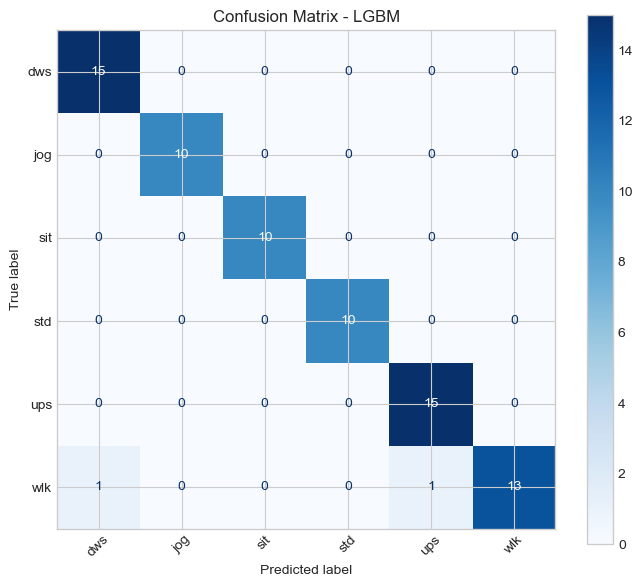

In [10]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

# combined_features가 없으면 저장된 결합 특징 파일을 먼저 불러옵니다.
if 'combined_features' not in globals():
    base_dir = Path.cwd()
    combined_path = base_dir / 'all_model_features.csv'
    if combined_path.exists():
        combined_features = pd.read_csv(combined_path)
    else:
        peak_features = pd.read_csv(base_dir / 'peak_features.csv')
        changepoint_features = pd.read_csv(base_dir / 'changepoint_features.csv')
        summary_features = pd.read_csv(base_dir / 'sensor_summary_features.csv')
        for df in [peak_features, changepoint_features, summary_features]:
            df['id'] = df['id'].astype(str)
            df['exp_no'] = df['exp_no'].astype(str)
        combined_features = (
            peak_features
            .merge(changepoint_features, on=['exp_no', 'id', 'activity'], how='inner', validate='one_to_one')
            .merge(summary_features, on=['exp_no', 'id', 'activity'], how='inner', validate='one_to_one')
        )

# exp_no, id, activity를 제외한 나머지를 입력변수로 사용
feature_cols = [col for col in combined_features.columns if col not in ['exp_no', 'id', 'activity']]

X = combined_features[feature_cols].fillna(0.0)
y = combined_features['activity']
groups = combined_features['id'].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

models = {
    'RF': RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced',
        random_state=42,
        n_jobs=1,
    ),
    'XGB': XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=1,
    ),
    'LGBM': LGBMClassifier(
        n_estimators=350,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=42,
        verbose=-1,
        n_jobs=1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_rows = []
fitted_models = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    fitted_models[name] = model
    model_rows.append({
        'model': name,
        'cv_accuracy_mean': cv_scores.mean(),
        'cv_accuracy_std': cv_scores.std(ddof=1),
        'test_accuracy': accuracy_score(y_test, pred),
        'test_macro_f1': f1_score(y_test, pred, average='macro'),
    })

model_result = pd.DataFrame(model_rows).sort_values(
    ['test_accuracy', 'cv_accuracy_mean'],
    ascending=False,
).reset_index(drop=True)

best_model_name = model_result.loc[0, 'model']
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)

display(model_result.round(4))

print('best model:', best_model_name)
print('test accuracy:', round(accuracy_score(y_test, best_pred), 4))
print('test macro_f1:', round(f1_score(y_test, best_pred, average='macro'), 4))
print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()


## 7. 변수 중요도

최고 모델이 트리 기반 모델 -> 중요도 확인 가능
모델에 따라 기본 중요도 또는 permutation importance를 사용


importance method: feature_importances_


,feature,importance
57,rotationRate.y_mean,594
74,userAcceleration.x_skew,341
76,userAcceleration.y_std,337
85,userAcceleration.z_median,301
81,userAcceleration.z_mean,299
79,userAcceleration.y_median,288
28,attitude.yaw_std,258
24,attitude.pitch_max,243
101,rot_acc_std_ratio,229
98,magrotationRate_skew,210


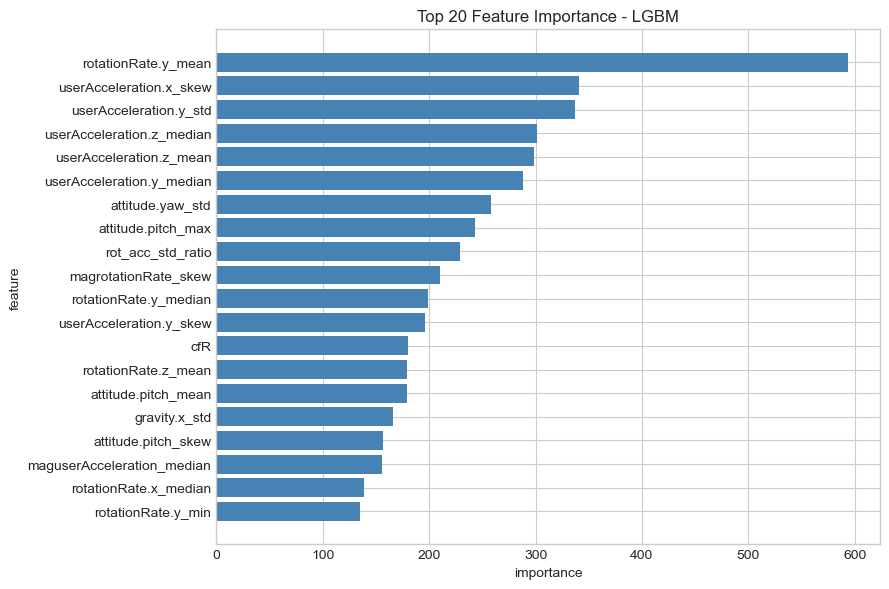

In [11]:
if hasattr(best_model, 'feature_importances_'):
    importance_values = best_model.feature_importances_
    importance_method = 'feature_importances_'
else:
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        scoring='accuracy',
    )
    importance_values = perm.importances_mean
    importance_method = 'permutation_importance'

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance_values,
}).sort_values('importance', ascending=False)

print('importance method:', importance_method)
display(importance_df.head(20).round(4))

plt.figure(figsize=(9, 6))
top_importance = importance_df.head(20).sort_values('importance')
plt.barh(top_importance['feature'], top_importance['importance'], color='steelblue')
plt.title(f'Top 20 Feature Importance - {best_model_name}')
plt.xlabel('importance')
plt.ylabel('feature')
plt.tight_layout()
plt.show()


## 8. 참고용 비교

변화점만 쓸 때와, 피크/요약 통계까지 합쳤을 때 성능 차이를 간단히 비교


In [12]:
compare_sets = {
    'changepoint_only': cp_cols,
    'peak_plus_changepoint': peak_cols + cp_cols,
    'all_features': feature_cols,
}

compare_rows = []
compare_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=1,
)

for set_name, cols in compare_sets.items():
    subset_X = combined_features[cols].fillna(0.0)
    subset_train = subset_X.iloc[train_idx]
    subset_test = subset_X.iloc[test_idx]

    cv_scores = cross_val_score(compare_model, subset_train, y_train, cv=cv, scoring='accuracy')
    compare_model.fit(subset_train, y_train)
    pred = compare_model.predict(subset_test)

    compare_rows.append({
        'feature_set': set_name,
        'n_features': len(cols),
        'cv_accuracy_mean': cv_scores.mean(),
        'test_accuracy': accuracy_score(y_test, pred),
    })

compare_result = pd.DataFrame(compare_rows).sort_values('test_accuracy', ascending=False)
display(compare_result.round(4))


,feature_set,n_features,cv_accuracy_mean,test_accuracy
2,all_features,104,0.9614,0.9067
1,peak_plus_changepoint,15,0.6175,0.5600
0,changepoint_only,6,0.3509,0.4000
